In [1]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np

In [3]:
import yfinance as yf
from datetime import timedelta

df = pd.read_csv('aapl-merged-T.csv')
df['ts_event'] = pd.to_datetime(df['ts_event'], utc=True) # time standard
df = df.sort_values('ts_event').reset_index(drop=True) # date sort
df['Timestamp'] = pd.to_datetime(df['ts_event'])
df['Date'] = df['Timestamp'].dt.date
# Calculate the earliest and latest dates in 'df'
earliest_date = df['Date'].min()
latest_date = df['Date'].max()
# Adjust 'start_date' and 'end_date' based on 'df'
start_date = earliest_date - timedelta(days=30)  # Earliest date minus 30 days
end_date = latest_date + timedelta(days=1)       # Latest date plus 1 day
start_date_str = start_date.strftime('%Y-%m-%d')
end_date_str = end_date.strftime('%Y-%m-%d')
# code to download daily volume and close price
data = yf.download('AAPL', start=start_date_str, end=end_date_str, interval='1d')
data = data.reset_index()
# Handle MultiIndex columns if present
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.droplevel(level=1)
data['Return'] = data['Adj Close'].pct_change()
data['Volatility'] = data['Return'].rolling(window=5).std()  # 5-day rolling volatility
data['ADV'] = data['Volume'].rolling(window=10).mean() # 10-day rolling average daily volume
data = data.dropna()
# Ensure 'Date' column in 'data' matches the format in 'df'
data['Date'] = data['Date'].dt.date
merged_df = pd.merge(df, data, on='Date', how='left')
# print(merged_df.head())
merged_df = merged_df[['ts_event','bid_fill','ask_fill','Signed Volume','best_bid','best_ask','Volatility','ADV']]

market_open_time = pd.to_datetime('13:30:00').time()  # Market opens at 13:30:00
market_close_time = pd.to_datetime('20:00:00').time()  # Market closes at 19:59:59

# Set 'ts_event' as the index
merged_df.set_index('ts_event', inplace=True)
# Filter data between market open and close times
df_market = merged_df.between_time(market_open_time, market_close_time)

# Aggregation
df_minute = df_market.resample('1min').agg({
    'bid_fill': 'sum',
    'ask_fill': 'sum',
    'Signed Volume': 'sum',
    'best_bid': 'max',
    'best_ask': 'min',
    'Volatility': 'max',
    'ADV': 'max',
})
df_minute = df_minute.dropna(subset=['best_bid']) # downsample will fill NaNs to out-of-market hours
df_minute = df_minute.reset_index()
df_minute['mid_price'] = (df_minute['best_bid'] + df_minute['best_ask']) / 2
print(df_minute.head(), df_minute.shape)

[*********************100%***********************]  1 of 1 completed

                   ts_event  bid_fill  ask_fill  Signed Volume  best_bid  \
0 2024-10-21 13:30:00+00:00   71844.0   37408.0        34436.0    235.46   
1 2024-10-21 13:31:00+00:00   12953.0   19161.0        -6208.0    235.24   
2 2024-10-21 13:32:00+00:00   19983.0   12031.0         7952.0    234.80   
3 2024-10-21 13:33:00+00:00   11981.0   11332.0          649.0    235.01   
4 2024-10-21 13:34:00+00:00    9455.0   13864.0        -4409.0    235.05   

   best_ask  Volatility         ADV  mid_price  
0    234.72    0.008558  37978500.0    235.090  
1    234.76    0.008558  37978500.0    235.000  
2    234.56    0.008558  37978500.0    234.680  
3    234.68    0.008558  37978500.0    234.845  
4    234.79    0.008558  37978500.0    234.920   (9344, 9)


In [4]:
df_minute['delta_p'] = df_minute['mid_price'].diff()
df_minute['delta_Q'] = df_minute['Signed Volume'] * df_minute['Volatility'] / df_minute['ADV']

#df_minute=df_minute.dropna(subset=['delta_p', 'delta_Q'])
X = df_minute[['delta_Q']].values[1:]
Y = df_minute['delta_p'].values[1:]
model = LinearRegression()
model.fit(X, Y)
lambda_value = model.coef_[0]
print(lambda_value)

18739.441082462687


In [5]:
import math
# set beta to hour frequency
h_minutes = 50 # hour-wise frequency # it should be set to 1 min
#input is h_minutes: h_minutes=60mins means the traded volume will influence the following 60 mins (exponential decay)
h_hours = h_minutes / 60

# Calculate beta using half-life transformation
beta = math.log(2) / h_hours
df_minute = df_minute.reset_index(drop=True)
lambda_t = lambda_value


def add_price_impact(data,lambda_t, beta):
    
    data['date'] = data['ts_event'].dt.date
    data['time'] = data['ts_event'].dt.time
    
    def calculate_price_impact(group):
        I = [0]  
        for t in range(1, len(group)): 
            I_next = I[-1] - I[-1] * beta + lambda_t * group.iloc[t-1]['Signed Volume'] * group.iloc[t-1]['Volatility']/ group.iloc[t-1]['ADV']
            I.append(I_next) 
        return pd.Series(I, index=group.index)
    
    
    data['price_impact'] = data.groupby('date').apply(calculate_price_impact,include_groups=False).reset_index(level=0, drop=True)
    data['unperturbed_price'] = data['mid_price'] - data['price_impact']
    return data

    

def determined_strategy(data):
    """
    Function to estimate alpha.
    Args:
        data (pd.DataFrame): Financial data with 'ts_event' and 'price' columns.

    Returns:
        dict: Keys as dates and values as calculated price differences.
    """
    # Extract date and time components
    data['date'] = data['ts_event'].dt.date
    data['time'] = data['ts_event'].dt.time

    # Get the closing price for each date
    end_time = pd.to_datetime('20:00:00').time()
    closing_prices = data[data['time'] == end_time].set_index('date')['unperturbed_price']

    # Calculate the new prices for each date
    def calculate_difference(row):
        return row['unperturbed_price'] - closing_prices.get(row['date'], np.nan)
    data['determined_alpha'] = data.apply(calculate_difference, axis=1)
    data.drop('date', axis=1, inplace=True)
    data.drop('time', axis=1, inplace=True)

    # Aggregate results by date
    #result = filtered_data.groupby('date')['calculated_price'].apply(list).to_dict()

    return data
res = add_price_impact(df_minute,lambda_t,beta)
res = determined_strategy(res)

In [6]:
def nu(data, beta, lambda_t, Q_0, T=390):
    """
    Function to estimate nu.
    Args:
        data (pd.DataFrame): Financial data with 'ts_event' and 'determined_alpha' columns.
        beta (float): A parameter.
        lambda_t (float): Another parameter.
        Q_0: Input of the strategy (assume side / size / timeframe(default to be 1 day) )
        T (float): Total time, default is 390 minutes each day.

    Returns:
        pd.DataFrame: Original data with a new 'determined_nu' column.
    """
    data = data.copy()  # Avoid modifying the original DataFrame
    data['date'] = data['ts_event'].dt.date
    data['time'] = data['ts_event'].dt.time
    start_time = pd.to_datetime('13:30:00').time()
    
    def calculate_nu(group):
        # Get 'determined_alpha' at start_time
        q_0 = Q_0 * group['Volatility'] / group['ADV']
        start_alpha_series = group.loc[group['time'] == start_time, 'determined_alpha']
        if not start_alpha_series.empty:
            start_alpha = start_alpha_series.iloc[0]
        else:
            # Handle case where start_time is not present
            start_alpha = 0  # Or use an appropriate default value
        start_alpha = np.full(len(group),start_alpha)
        summed_alpha = group['determined_alpha'].sum()
        summed_alpha = np.full(len(group),summed_alpha)
        res = (start_alpha + beta * summed_alpha + 2 * lambda_t * q_0) * -1 / (2 + beta * T)
        return pd.Series(res, index=group.index)
    
    # Compute 'determined_nu' per date
    data['determined_nu'] = data.groupby('date').apply(calculate_nu,include_groups=False).reset_index(level=0, drop=True)
    
    
    # Clean up
    data.drop(['date', 'time'], axis=1, inplace=True)
    return data

Q_0 = 3900000 # we assume that the client hope to sell 390 shares of AAPL today
res = nu(res, beta, lambda_t, Q_0)

In [7]:
def alpha_prime(data,beta):
    """
    Function to estimate the difference of 'determined_alpha' per day.
    Args:
        data (pd.DataFrame): Financial data with 'ts_event' and 'determined_alpha' columns.

    Returns:
        pd.DataFrame: Original data with a new 'determined_alpha_prime' column.
    """
    data = data.copy()  # Avoid modifying the original DataFrame
    data['date'] = data['ts_event'].dt.date
    data['time'] = data['ts_event'].dt.time
    end_time = pd.to_datetime('20:00:00').time()

    def calculate_alpha_prime(group):
        # Ensure the group is sorted by 'ts_event' if necessary
        group = group.sort_values('ts_event')
        res = group['determined_alpha'].diff()
        return res

    def calculate_I_prime(group):
        res = group['price_impact'].diff().fillna(0)
        return res
    
    def calculate_I_star(group):
        '''stochastic I_star here we assume we have perfect alpha estimation
        '''
        res = ((group['determined_alpha'] - (group['determined_alpha_prime'] / beta) + group['determined_nu'])/2).fillna(0)
        res[group['time']==end_time] = group['determined_nu'].iloc[0]
        return res

    def calculate_I_star_prime(group):
        res = group['I_star_t'].diff().fillna(0)
        return res
    def calculate_delta_Q_star(group):
        res = ((group['I_star_t'].diff() + beta * group['I_star_t'])/lambda_t).fillna(0)
        return res
    
    # Compute 'determined_alpha_prime' per date and align with original index
    data['determined_alpha_prime'] = data.groupby('date').apply(calculate_alpha_prime,include_groups=False).reset_index(level=0, drop=True)
    data['I_star_t'] = data.groupby('date').apply(calculate_I_star,include_groups=False).reset_index(level=0, drop=True)
    data['I_prime'] = data.groupby('date').apply(calculate_I_prime,include_groups=False).reset_index(level=0, drop=True)
    data['I_star_prime'] = data.groupby('date').apply(calculate_I_star_prime,include_groups=False).reset_index(level=0, drop=True)
    data['delta_Q_star'] = data.groupby('date').apply(calculate_delta_Q_star,include_groups=False).reset_index(level=0, drop=True)
    
    # Clean up
    data.drop(['date', 'time'], axis=1, inplace=True)
    return data
res = alpha_prime(res,beta)

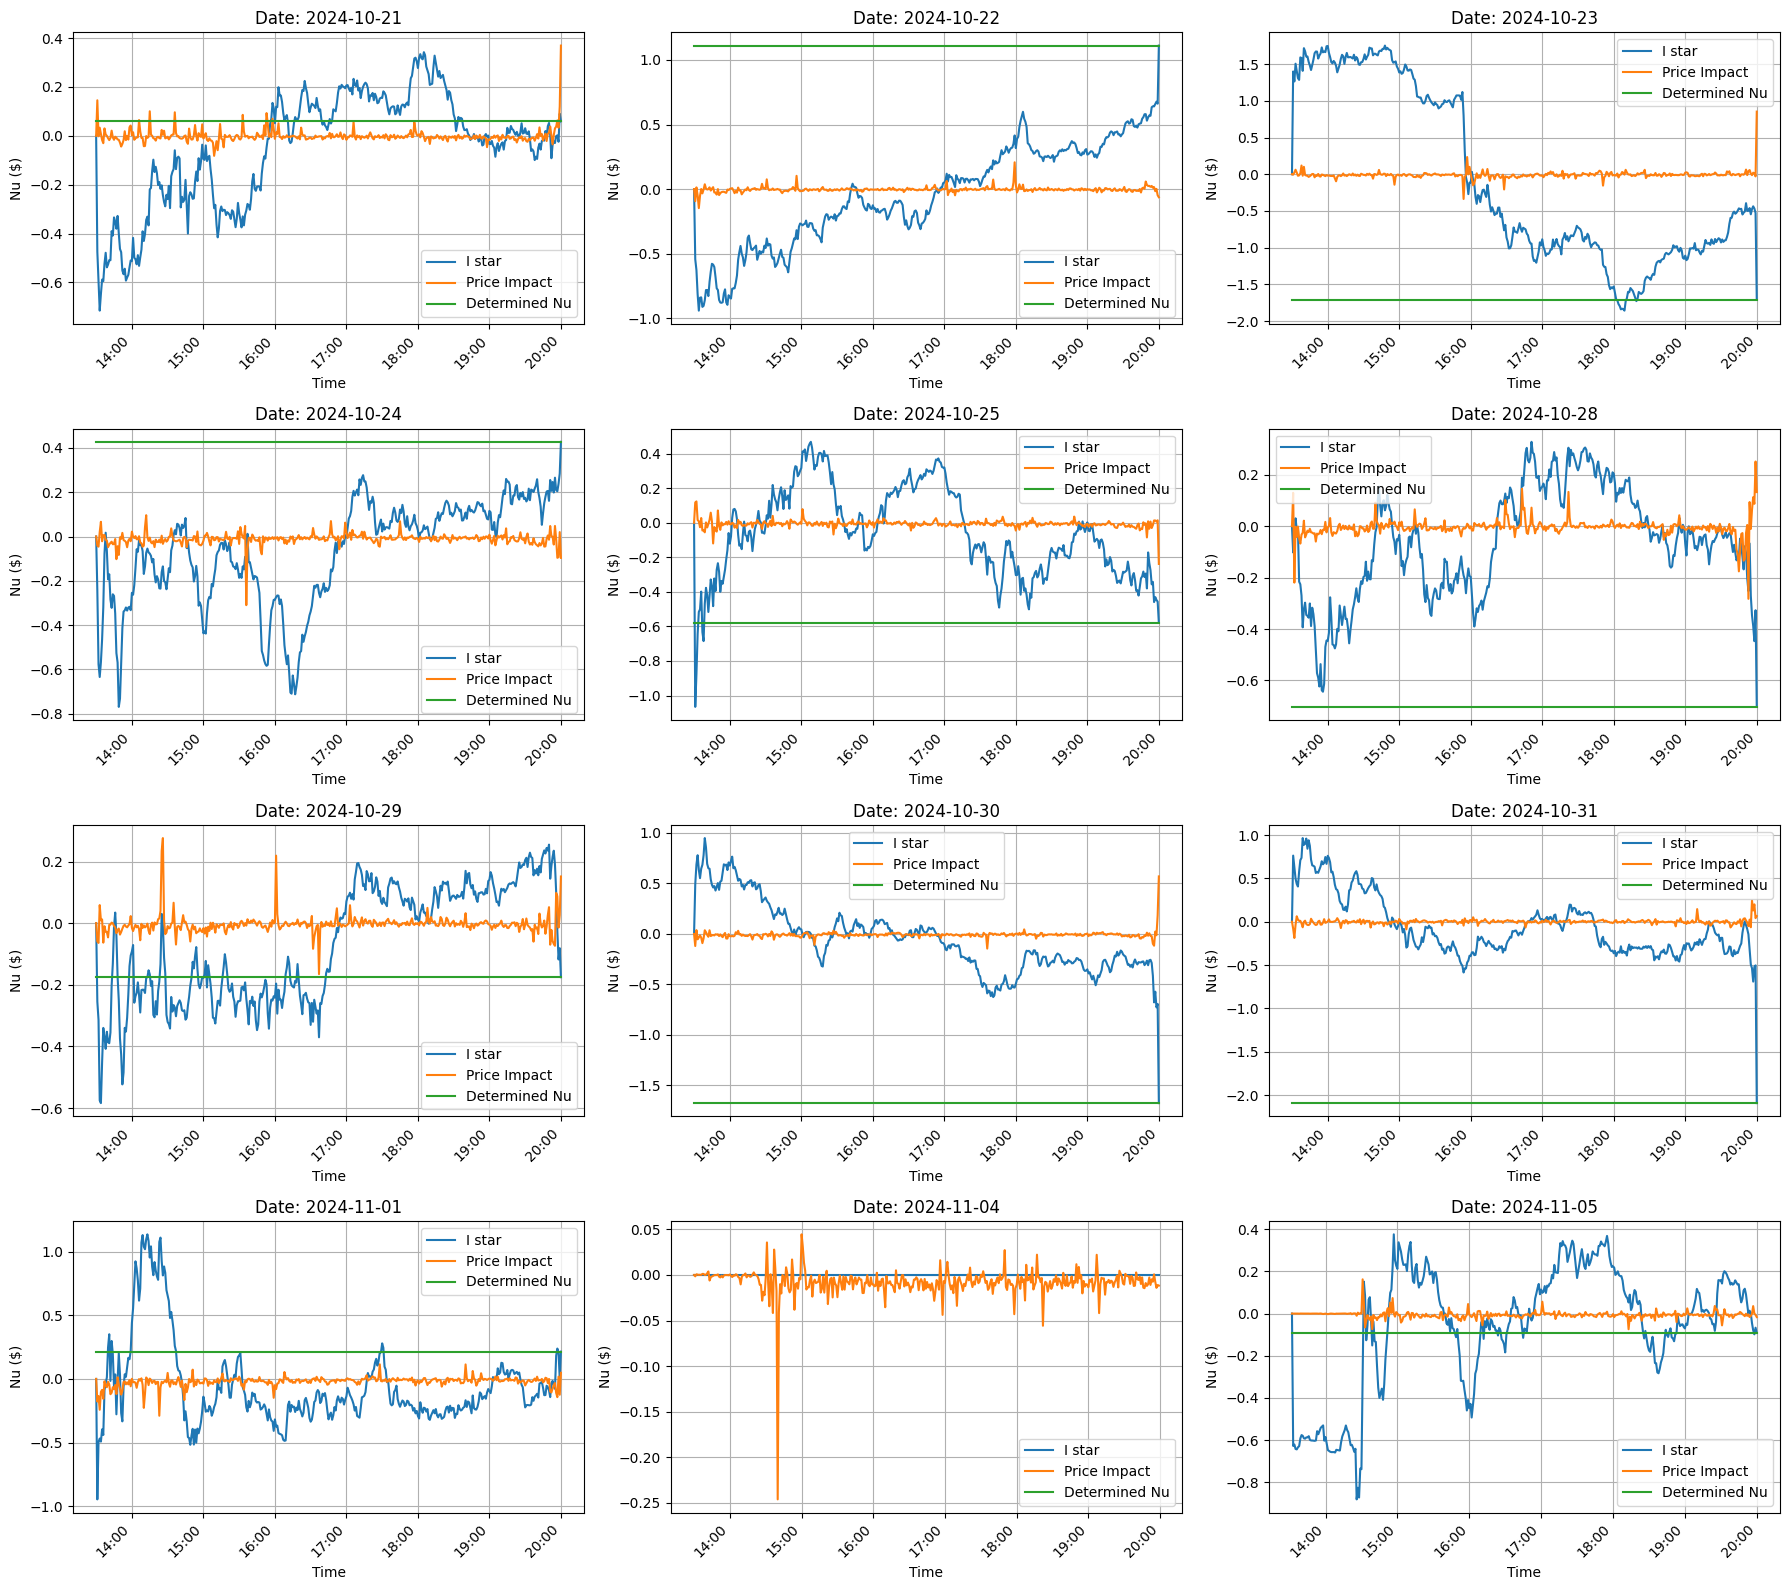

In [8]:
import matplotlib.dates as mdates

res['ts_event'] = pd.to_datetime(res['ts_event'])
res['date'] = res['ts_event'].dt.date

# Get the list of unique dates and select the first 6 days
unique_dates = res['date'].unique()
first_6_days = unique_dates[:12]

# Filter the DataFrame to include only the first 6 days
filtered_res = res[res['date'].isin(first_6_days)].copy()

# Sort the data by 'ts_event' within each day
filtered_res.sort_values(['date', 'ts_event'], inplace=True)

# Prepare for plotting
num_days = len(first_6_days)
nrows = 4
ncols = 3

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 16))
axes = axes.flatten()  # Flatten the axes array for easy indexing

# Loop over each day and plot the time series
for i, date in enumerate(first_6_days):
    # Get the data for the current day
    day_data = filtered_res[filtered_res['date'] == date]
    
    # Plotting

    ax = axes[i]
    ax.plot(day_data['ts_event'], day_data['I_star_t'], label='I star')
    ax.plot(day_data['ts_event'], day_data['price_impact'], label='Price Impact')
    ax.plot(day_data['ts_event'], day_data['determined_nu'], label='Determined Nu')
    
    # Formatting the x-axis to show time only
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.set_xlabel('Time')
    ax.set_ylabel('Nu ($)')
    ax.set_title(f'Date: {date}')
    ax.legend()
    ax.grid(True)
    
    # # Rotate x-axis labels if needed
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# Hide any unused subplots if there are any
for j in range(i+1, nrows * ncols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [9]:
res['myopic_market_obj'] = (beta * res['determined_alpha'] * res['price_impact'] - res['determined_alpha_prime'] * res['price_impact'] - beta*res['price_impact']**2).fillna(0)
res['myopic_opt_obj'] = (beta * res['determined_alpha'] * res['I_star_t'] - res['determined_alpha_prime'] * res['I_star_t'] - beta*res['I_star_t']**2).fillna(0)
def PnL(data,beta,lambda_t, Q_0):
    """
    Function to add column PnL.
    Args:
        data (pd.DataFrame): Financial data with 'ts_event' and 'determined_alpha' columns.
        Q_0 : input of the strategy, from client
    Returns:
        pd.DataFrame: Original data with a new 'determined_nu' column.
    """
    data = data.copy()  # Avoid modifying the original DataFrame
    data['date'] = data['ts_event'].dt.date
    data['time'] = data['ts_event'].dt.time
    start_time = pd.to_datetime('13:30:00').time()
    end_time = pd.to_datetime('20:00:00').time()
    
    def calculate_optimal_PnL(group):
        # Get 'determined_alpha' at start_time
        res = ((group['determined_alpha'] - group['I_star_t']) * group['delta_Q_star']).cumsum()
        return res
    
    def calculate_PnL(group):
        # Get 'determined_alpha' at start_time
        res = ((group['determined_alpha'] - group['price_impact']) * group['delta_Q']).cumsum()
        return res

    def calculate_integral_test_1(group):
        res = ((group['determined_alpha'] - group['price_impact']) * (beta*group['price_impact']+group['I_prime'])).cumsum()
        res = res/lambda_t
        return res

    def calculate_integral_test_1_optimal(group):
        res = ((group['determined_alpha'] - group['I_star_t']) * (beta*group['I_star_t']+group['I_star_prime'])).cumsum()
        res = res/lambda_t
        return res
        

    def calculate_integral(group):
        a=group['myopic_market_obj'].sum() + group[group['time'] == end_time]['determined_alpha'] * group[group['time'] == end_time]['price_impact']
        a=a-(group[group['time'] == end_time]['price_impact'])**2/2
        a=a/lambda_t
        return a
    
    def calculate_optimal_integral(group):
        a=group['myopic_opt_obj'].sum()+group[group['time'] == end_time]['determined_alpha'] * group[group['time'] == end_time]['I_star_t']
        a=a-(group[group['time'] == end_time]['I_star_t'])**2/2
        a=a/lambda_t
        return a

    def calculate_optimal_position(group):
        summed_alpha = group['determined_alpha'].sum()
        if group[group['time'] == start_time].empty:
            #Q0 = 0  # Default value
            q_0 = 0
        else:
            #Q0 = -1 * (group[group['time'] == start_time]['determined_alpha'].iloc[0] + beta * summed_alpha) / (2 * lambda_t) # nu=0
            q_0 = Q_0 * group['Volatility'] / group['ADV']
        q0_vector = np.full(len(group), q_0)
        a = q0_vector + group['delta_Q_star'].cumsum()
        return a
        
    def calculate_vwap(group):
        VWAP = (group['bid_fill'] + group['ask_fill'])/((group['bid_fill']+group['ask_fill']).sum())
        summed_alpha = group['determined_alpha'].sum()
        if group[group['time'] == start_time].empty:
            #Q0 = 0  # Default value
            q_0 = 0
        else:
            q_0 = Q_0 * group['Volatility'] / group['ADV']
        q0_vector = np.full(len(group), q_0)
        position_vwap = q0_vector - q0_vector * VWAP.cumsum()
        return position_vwap
    def calculate_vwap_delta_Q(group):
        res = group['vwap_position'].diff().fillna(0)
        return res
    def calculate_vwap_price_impact(group):
        I = [0]  
        for t in range(1, len(group)): 
            I_next = I[-1] - I[-1] * beta + lambda_t * group.iloc[t-1]['vwap_delta_Q']
            I.append(I_next) 
        return pd.Series(I, index=group.index)
        
    def calculate_vwap_PnL(group):
        res = ((group['determined_alpha'] - group['vwap_I']) * group['vwap_delta_Q']).cumsum()
        return res
     

    def calculate_twap(group):
        TWAP = np.full(len(group), 1)/len(group)
        summed_alpha = group['determined_alpha'].sum()
        if group[group['time'] == start_time].empty:
            #Q0 = 0  # Default value
            q_0 = 0
        else:
            q_0 = Q_0 * group['Volatility'] / group['ADV']
        q0_vector = np.full(len(group), q_0)
        position_twap = q0_vector - q0_vector * TWAP.cumsum()
        return pd.Series(position_twap, index=group.index)
    
    def calculate_twap_delta_Q(group):
        res = group['twap_position'].diff().fillna(0)
        return res
    def calculate_twap_price_impact(group):
        I = [0]
        for t in range(1, len(group)):  
            I_next = I[-1] - I[-1] * beta + lambda_t * group.iloc[t-1]['twap_delta_Q']
            I.append(I_next)
        return pd.Series(I, index=group.index)

    def calculate_twap_PnL(group):
        res = ((group['determined_alpha'] - group['twap_I']) * group['twap_delta_Q']).cumsum()
        return res    
        
    
    data['optimal_PnL'] = data.groupby('date').apply(calculate_optimal_PnL,include_groups=False).reset_index(level=0, drop=True)
    data['PnL'] = data.groupby('date').apply(calculate_PnL,include_groups=False).reset_index(level=0, drop=True)
    data['integral'] = data.groupby('date').apply(calculate_integral,include_groups=False).reset_index(level=0, drop=True)
    data['optimal_integral'] = data.groupby('date').apply(calculate_optimal_integral,include_groups=False).reset_index(level=0, drop=True)
    data['integral_test1'] = data.groupby('date').apply(calculate_integral_test_1,include_groups=False).reset_index(level=0, drop=True)
    data['integral_test1_opt'] = data.groupby('date').apply(calculate_integral_test_1_optimal,include_groups=False).reset_index(level=0, drop=True)
    data['optimal_position'] = data.groupby('date').apply(calculate_optimal_position,include_groups=False).reset_index(level=0, drop=True)
    data['vwap_position'] = data.groupby('date').apply(calculate_vwap, include_groups=False).reset_index(level=0, drop=True)
    data['vwap_delta_Q'] = data.groupby('date').apply(calculate_vwap_delta_Q, include_groups=False).reset_index(level=0, drop=True)
    data['vwap_I'] = data.groupby(data['date']).apply(calculate_vwap_price_impact,include_groups=False).reset_index(level=0, drop=True)
    data['vwap_PnL'] = data.groupby('date').apply(calculate_vwap_PnL, include_groups=False).reset_index(level=0, drop=True)
    data['twap_position'] = data.groupby('date').apply(calculate_twap,include_groups=False).reset_index(level=0, drop=True)
    data['twap_delta_Q'] = data.groupby('date').apply(calculate_twap_delta_Q, include_groups=False).reset_index(level=0, drop=True)
    data['twap_I'] = data.groupby(data['date']).apply(calculate_twap_price_impact,include_groups=False).reset_index(level=0, drop=True)
    data['twap_PnL'] = data.groupby('date').apply(calculate_twap_PnL, include_groups=False).reset_index(level=0, drop=True)
    # Clean up
    data.drop(['date', 'time'], axis=1, inplace=True)
    return data
res = PnL(res,beta,lambda_t,Q_0)

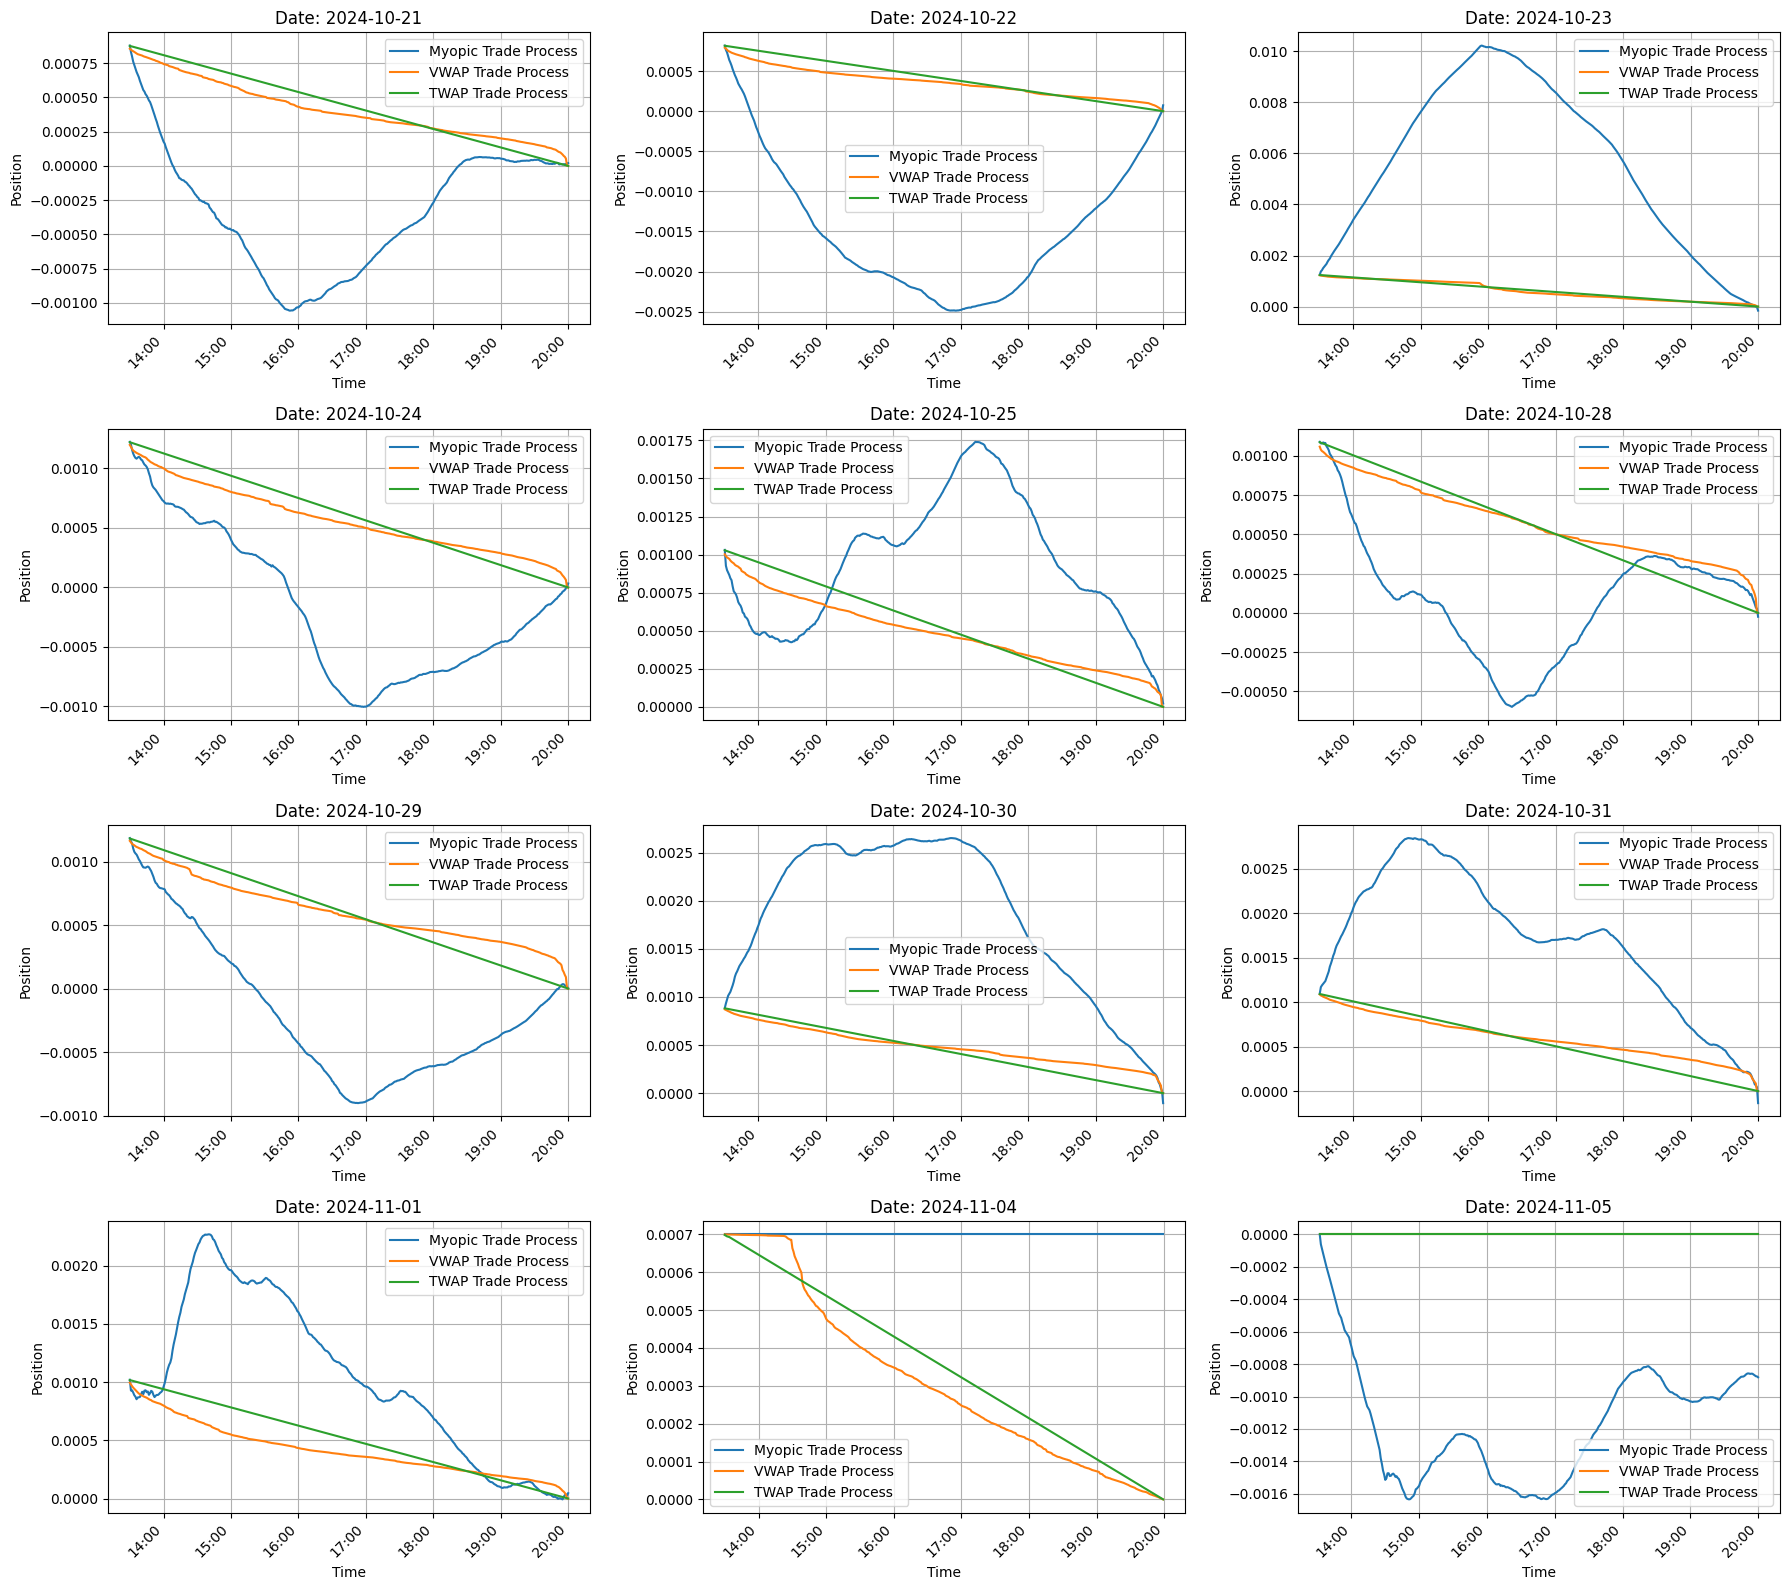

In [10]:
import matplotlib.dates as mdates

res['ts_event'] = pd.to_datetime(res['ts_event'])
res['date'] = res['ts_event'].dt.date

# Get the list of unique dates and select the first 6 days
unique_dates = res['date'].unique()
first_6_days = unique_dates[:12]

# Filter the DataFrame to include only the first 6 days
filtered_res = res[res['date'].isin(first_6_days)].copy()

# Sort the data by 'ts_event' within each day
filtered_res.sort_values(['date', 'ts_event'], inplace=True)

# Prepare for plotting
num_days = len(first_6_days)
nrows = 4
ncols = 3

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 16))
axes = axes.flatten()  # Flatten the axes array for easy indexing

# Loop over each day and plot the time series
for i, date in enumerate(first_6_days):
    # Get the data for the current day
    day_data = filtered_res[filtered_res['date'] == date]
    
    # Plotting

    ax = axes[i]
    ax.plot(day_data['ts_event'], day_data['optimal_position'], label='Myopic Trade Process')
    ax.plot(day_data['ts_event'], day_data['vwap_position'], label='VWAP Trade Process')
    ax.plot(day_data['ts_event'], day_data['twap_position'], label='TWAP Trade Process')
    
    
    # Formatting the x-axis to show time only
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.set_xlabel('Time')
    ax.set_ylabel('Position')
    ax.set_title(f'Date: {date}')
    ax.legend()
    ax.grid(True)
    
    # # Rotate x-axis labels if needed
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# Hide any unused subplots if there are any
for j in range(i+1, nrows * ncols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


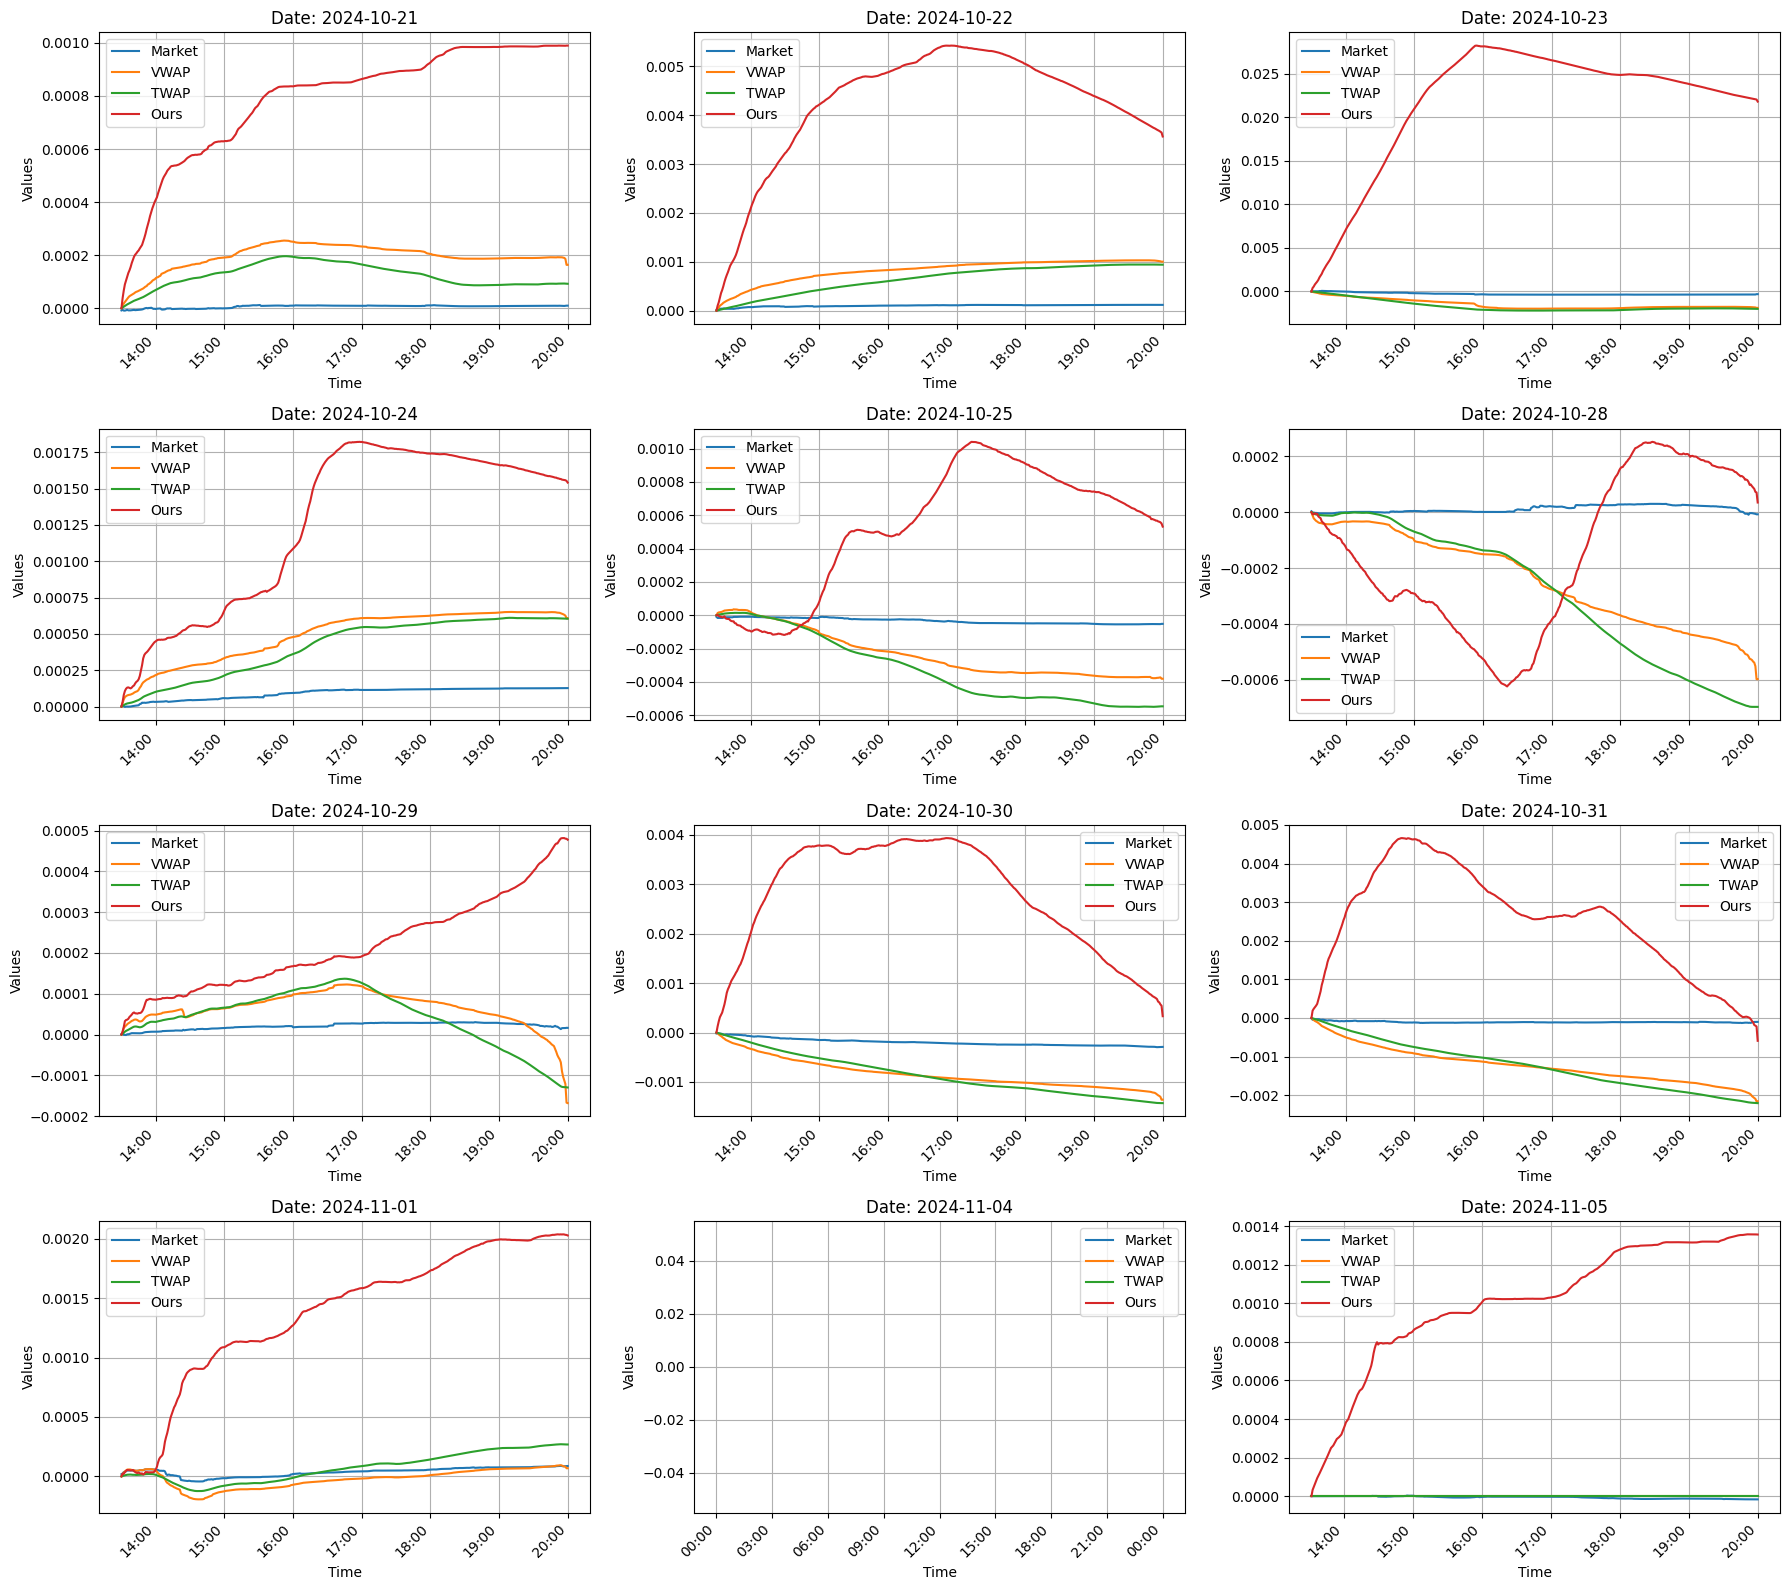

In [11]:
import matplotlib.dates as mdates

res['ts_event'] = pd.to_datetime(res['ts_event'])
res['date'] = res['ts_event'].dt.date

# Get the list of unique dates and select the first 6 days
unique_dates = res['date'].unique()
first_6_days = unique_dates[:12]

# Filter the DataFrame to include only the first 6 days
filtered_res = res[res['date'].isin(first_6_days)].copy()

# Sort the data by 'ts_event' within each day
filtered_res.sort_values(['date', 'ts_event'], inplace=True)

# Prepare for plotting
num_days = len(first_6_days)
nrows = 4
ncols = 3

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 16))
axes = axes.flatten()  # Flatten the axes array for easy indexing

# Loop over each day and plot the time series
for i, date in enumerate(first_6_days):
    # Get the data for the current day
    day_data = filtered_res[filtered_res['date'] == date]
    
    # Plotting
    ax = axes[i]
    ax.plot(day_data['ts_event'], day_data['PnL'], label='Market')
    ax.plot(day_data['ts_event'], day_data['vwap_PnL'], label='VWAP')
    ax.plot(day_data['ts_event'], day_data['twap_PnL'], label='TWAP')
    ax.plot(day_data['ts_event'], day_data['optimal_PnL'], label='Ours')
    
    # Formatting the x-axis to show time only
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.set_xlabel('Time')
    ax.set_ylabel('Values')
    ax.set_title(f'Date: {date}')
    ax.legend()
    ax.grid(True)
    
    # Rotate x-axis labels if needed
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# Hide any unused subplots if there are any
for j in range(i+1, nrows * ncols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()
